<a href="https://colab.research.google.com/github/rahajengs/Praktik-Penambangan-Data-dan-Analisis-Bisnis/blob/main/Praktik%20KNN_PDAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/rahajengs/Praktik-Penambangan-Data-dan-Analisis-Bisnis/refs/heads/main/data_ecommerce_customer_churn.csv"
df = pd.read_csv(url)

df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Data Understanding

In [ ]:
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


,count
Churn,
0,3267
1,674


Data Preprocessing

In [ ]:
#Mengisi nilai yang hilang dengan median untuk data numerik
from sklearn.impute import SimpleImputer
import numpy as np
imputer = SimpleImputer(strategy='median')
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encoding Kategorikal
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Split Data

In [ ]:
#Memisahkan Fitur (X) dan Target (Y)
X = df.drop('Churn', axis=1)
y = df['Churn']

#Normalisasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
Model KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
#Prediksi dan Evaluasi
y_pred = knn.predict(X_test)

Evaluasi Model

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8915304606240714
[[553  16]
 [ 57  47]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       569
           1       0.75      0.45      0.56       104

    accuracy                           0.89       673
   macro avg       0.83      0.71      0.75       673
weighted avg       0.88      0.89      0.88       673



K Terbaik

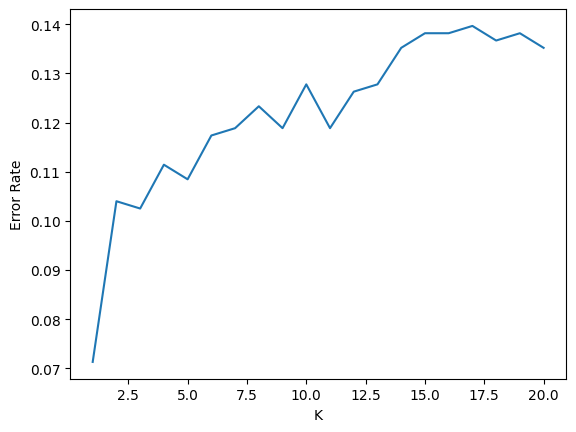

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

error_rate = []

for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.plot(range(1,21), error_rate)
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()